In [1]:
!pip3 install seaborn
!pip3 install statsmodels
!pip3 install tabulate

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, when
from pyspark.sql.functions import explode, avg
from pyspark.sql import functions as F
from pyspark.sql.functions import udf
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import countDistinct
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, VectorSizeHint
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.mllib.feature import Normalizer
import re
from tabulate import tabulate
from statsmodels.stats.outliers_influence import variance_inflation_factor


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

In [3]:
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

/opt/conda/lib/python3.7/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/12/05 16:30:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)

In [5]:
seed=42

In [6]:
#path = "/Users/acgid/Downloads/nba_stats/"
#Individual Statistics
file_1 = "Player Award Shares.csv" #Truth data and dependent variable
file_2 = "Player Totals.csv"
file_3 = "Player Per Game.csv"
file_4 = "Player Play By Play.csv"
file_5 = "Player Shooting.csv"
#Advanced Individual Statistics
file_6 = "Advanced.csv"
file_7 = "Per 36 Minutes.csv"
file_8 = "Per 100 Poss.csv"

In [7]:
award_df = spark.read.csv(file_1, header=True, inferSchema=True)
plyr_tot_df = spark.read.csv(file_2, header=True, inferSchema=True)
ppg_df = spark.read.csv(file_3, header=True, inferSchema=True)
plyr_pbp_df = spark.read.csv(file_4, header=True, inferSchema=True)
plyr_shtg_df = spark.read.csv(file_5, header=True, inferSchema=True)
adv_df = spark.read.csv(file_6, header=True, inferSchema=True)
plyr_p36min_df = spark.read.csv(file_7, header=True, inferSchema=True)
plyr_p100ps_df = spark.read.csv(file_8, header=True, inferSchema=True)

In [8]:
# filter for 1980 or higher
award_df_filtered = award_df.filter(award_df.season >= 1980)
print("This is award_df_filtered after filter:",award_df_filtered.count())

plyr_tot_df_filtered = plyr_tot_df.filter(plyr_tot_df.season >= 1980)
print("This is plyr_tot_df_filtered after filter:", plyr_tot_df_filtered.count())

ppg_df_filtered = ppg_df.filter(ppg_df.season >= 1980)
print("This is ppg_df_filtered after filter:", ppg_df_filtered.count())

plyr_pbp_df_filtered = plyr_pbp_df.filter(plyr_pbp_df.season >= 1980)
print("This is plyr_pbp_df_filtered after filter:", plyr_pbp_df_filtered.count())

plyr_shtg_df_filtered = plyr_shtg_df.filter(plyr_shtg_df.season >= 1980)
print("This is plyr_shtg_df_filtered after filter:", plyr_shtg_df_filtered.count())

adv_df_filtered = adv_df.filter(adv_df.season >= 1980)
print("This is adv_df_filtered after filter:", adv_df_filtered.count())

plyr_p36min_df_filtered = plyr_p36min_df.filter(plyr_p36min_df.season >= 1980)
print("This is plyr_p36min_df_filtered after filter:", plyr_p36min_df_filtered.count())

plyr_p100ps_df_filtered = plyr_p100ps_df.filter(plyr_p100ps_df.season >= 1980)
print("This is plyr_p100ps_df_filtered after filter:", plyr_p100ps_df_filtered.count())

This is award_df_filtered after filter: 2897
This is plyr_tot_df_filtered after filter: 24616
This is ppg_df_filtered after filter: 24616
This is plyr_pbp_df_filtered after filter: 17521
This is plyr_shtg_df_filtered after filter: 17521
This is adv_df_filtered after filter: 24616
This is plyr_p36min_df_filtered after filter: 24616
This is plyr_p100ps_df_filtered after filter: 24616


In [9]:
temp1 = plyr_tot_df_filtered.join(ppg_df_filtered, 
                                  on=["season", "lg", "player", "player_id", "age", "team", "pos", "g", "gs","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent","x3p_percent"], 
                                  how="left")
print("this is after merge:",temp1.count())


this is after merge: 24616


In [10]:
temp1.show()

25/12/05 16:31:14 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
+------+---+--------------------+---------+---+----+---+---+---+----------+-----------+------------+----------+-----------+----+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|fg_percent|x2p_percent|e_fg_percent|ft_percent|x3p_percent|  mp| fg| fga|x3p|x3pa|x2p|x2pa| ft|fta|orb|drb|trb|ast|stl|blk|tov| pf| pts|trp_dbl|mp_per_game|fg_per_game|fga_per_game|x3p_per_game|x3pa_per_game|x2p_per_game|x2pa_per_game|ft_per_game|fta_per_game|orb_per_game|drb_per_game|trb_per_game|ast_per_game|stl

In [11]:
temp1.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('fg_percent', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft_percent', 'string'),
 ('x3p_percent', 'string'),
 ('mp', 'string'),
 ('fg', 'int'),
 ('fga', 'int'),
 ('x3p', 'string'),
 ('x3pa', 'string'),
 ('x2p', 'string'),
 ('x2pa', 'string'),
 ('ft', 'int'),
 ('fta', 'int'),
 ('orb', 'string'),
 ('drb', 'string'),
 ('trb', 'string'),
 ('ast', 'int'),
 ('stl', 'string'),
 ('blk', 'string'),
 ('tov', 'string'),
 ('pf', 'string'),
 ('pts', 'int'),
 ('trp_dbl', 'string'),
 ('mp_per_game', 'string'),
 ('fg_per_game', 'double'),
 ('fga_per_game', 'double'),
 ('x3p_per_game', 'string'),
 ('x3pa_per_game', 'string'),
 ('x2p_per_game', 'string'),
 ('x2pa_per_game', 'string'),
 ('ft_per_game', 'double'),
 ('fta_per_game', 'double'),
 ('orb_per_game', 'string'),
 ('drb_per_game', 'string

In [12]:
temp2 = plyr_pbp_df_filtered.join(plyr_shtg_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

print("this is after merge:",temp2.count())



this is after merge: 17521


In [13]:
temp2.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+----------------------------+----------------------------+-------------------------+-----------------------+-----------------------+--------------------+------------+------------------------+----------------------+--------------------+---------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp|pg_percent|sg_percent|sf_percent|pf_percent|c_p

In [14]:
temp2.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'int'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'int'),
 ('mp', 'int'),
 ('pg_percent', 'string'),
 ('sg_percent', 'string'),
 ('sf_percent', 'string'),
 ('pf_percent', 'string'),
 ('c_percent', 'string'),
 ('on_court_plus_minus_per_100_poss', 'string'),
 ('net_plus_minus_per_100_poss', 'string'),
 ('bad_pass_turnover', 'int'),
 ('lost_ball_turnover', 'int'),
 ('shooting_foul_committed', 'int'),
 ('offensive_foul_committed', 'int'),
 ('shooting_foul_drawn', 'int'),
 ('offensive_foul_drawn', 'string'),
 ('points_generated_by_assists', 'int'),
 ('and1', 'int'),
 ('fga_blocked', 'int'),
 ('fg_percent', 'string'),
 ('avg_dist_fga', 'string'),
 ('percent_fga_from_x2p_range', 'string'),
 ('percent_fga_from_x0_3_range', 'string'),
 ('percent_fga_from_x3_10_range', 'string'),
 ('percent_fga_from_x10_16_range', 'string'),
 ('percent_fga_from_x16_3p_range', 'string'),
 ('perce

In [15]:
temp3_a = adv_df_filtered.join(plyr_p36min_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

temp3 = temp3_a.join(plyr_p100ps_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent", "x3p_percent"], 
                                  how="left")


print("this is after merge:",temp3.count())

this is after merge: 24616


In [16]:
temp3.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+----+----------+------+-----+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----+---+----+------+----+----+----+----+-------------+--------------+--------------+---------------+--------------+---------------+-------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+--------------+---------------+----------------+----------------+-----------------+----------------+-----------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+---------------+----------------+-----+-----+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp|fg_percent|x2p_percent|e_fg_percent|ft_percent|x3p_percent| per|ts_percent|x3p_ar|

In [17]:
temp3.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('mp', 'string'),
 ('fg_percent', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft_percent', 'string'),
 ('x3p_percent', 'string'),
 ('per', 'string'),
 ('ts_percent', 'string'),
 ('x3p_ar', 'string'),
 ('f_tr', 'string'),
 ('orb_percent', 'string'),
 ('drb_percent', 'string'),
 ('trb_percent', 'string'),
 ('ast_percent', 'string'),
 ('stl_percent', 'string'),
 ('blk_percent', 'string'),
 ('tov_percent', 'string'),
 ('usg_percent', 'string'),
 ('ows', 'string'),
 ('dws', 'string'),
 ('ws', 'string'),
 ('ws_48', 'string'),
 ('obpm', 'string'),
 ('dbpm', 'string'),
 ('bpm', 'string'),
 ('vorp', 'string'),
 ('fg_per_36_min', 'string'),
 ('fga_per_36_min', 'string'),
 ('x3p_per_36_min', 'string'),
 ('x3pa_per_36_min', 'string'),
 ('x2p_per_36_min', 'string'),
 ('x2pa_per_36_min', 'str

## Merge for Final dataset

Merge Temp1, temp2, & temp3 together. Below is an idea. Not decided how to go about that. 

In [18]:
temp4_a = temp1.join(temp2,
                     on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp","fg_percent"], 
                     how="left")
print("Join temp1 and temp 2:", temp4_a.count())


Join temp1 and temp 2: 24616


In [19]:
temp4 = temp4_a.join(temp3, 
                        on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent", "x3p_percent"], 
                        how="left")
print("Join temp4_a and temp3:", temp4.count())

Join temp4_a and temp3: 24616


In [20]:
award_df_filtered.show()

+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|season|         award|              player|player_id|age|first|pts_won|pts_max|share|winner|
+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|  2024|nba clutch_poy|       Stephen Curry|curryst01| 35|   45|    298|    495|0.602|  true|
|  2024|nba clutch_poy|       DeMar DeRozan|derozde01| 34|   34|    272|    495|0.549| false|
|  2024|nba clutch_poy|Shai Gilgeous-Ale...|gilgesh01| 25|   11|    160|    495|0.323| false|
|  2024|nba clutch_poy|        Nikola Jokić|jokicni01| 28|    4|     85|    495|0.172| false|
|  2024|nba clutch_poy|       Jalen Brunson|brunsja01| 27|    2|     26|    495|0.053| false|
|  2024|nba clutch_poy|         Luka Dončić|doncilu01| 24|    1|     16|    495|0.032| false|
|  2024|nba clutch_poy|        Kyrie Irving|irvinky01| 31|    0|     14|    495|0.028| false|
|  2024|nba clutch_poy|     Anthony Edwards|edwaran01| 22|  

In [21]:
temp4.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------

In [22]:
temp5 = temp4.join(award_df_filtered,
                   on=["season","player", "player_id", "age"],
                   how="left")

print("Merged with temp 4: ", temp5.count())

Merged with temp 4:  25169


In [23]:
temp5.show()


+------+--------------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------

In [24]:
dup_keys = (
    award_df_filtered
    .groupBy("season", "player", "player_id", "age")
    .agg(F.count("*").alias("cnt"))
    .filter("cnt > 1")
)

print("Duplicate keys in award_df_filtered:", dup_keys.count())
dup_keys.show(10)

Duplicate keys in award_df_filtered: 497
+------+-----------------+---------+---+---+
|season|           player|player_id|age|cnt|
+------+-----------------+---------+---+---+
|  2023|     Nikola Jokić|jokicni01| 27|  2|
|  1996|  Hakeem Olajuwon|olajuha01| 33|  2|
|  2007|   Gerald Wallace|wallage01| 24|  2|
|  2003| Andrei Kirilenko|kirilan01| 21|  2|
|  2019|Spencer Dinwiddie|dinwisp01| 25|  2|
|  2010|      Ben Wallace|wallabe01| 35|  2|
|  2008|       J.R. Smith|smithjr01| 22|  2|
|  2018|   Victor Oladipo|oladivi01| 25|  3|
|  2013|     Jarrett Jack| jackja01| 29|  2|
|  1999|     Vince Carter|cartevi01| 22|  2|
+------+-----------------+---------+---+---+
only showing top 10 rows



In [25]:
dupes_detail = award_df_filtered.join(
    dup_keys,
    on=["season", "player", "player_id", "age"],
    how="inner"
)
dupes_detail.show(20, truncate=False)

+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|season|player                 |player_id|age|award         |first|pts_won|pts_max|share|winner|cnt|
+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|2024  |Shai Gilgeous-Alexander|gilgesh01|25 |nba clutch_poy|11   |160    |495    |0.323|false |4  |
|2024  |Nikola Jokić           |jokicni01|28 |nba clutch_poy|4    |85     |495    |0.172|false |2  |
|2024  |Jalen Brunson          |brunsja01|27 |nba clutch_poy|2    |26     |495    |0.053|false |3  |
|2024  |Luka Dončić            |doncilu01|24 |nba clutch_poy|1    |16     |495    |0.032|false |2  |
|2024  |Anthony Edwards        |edwaran01|22 |nba clutch_poy|1    |6      |495    |0.012|false |2  |
|2024  |Jayson Tatum           |tatumja01|25 |nba clutch_poy|1    |5      |495    |0.01 |false |2  |
|2024  |Giannis Antetokounmpo  |antetgi01|29 |nba clutch_poy|0    |1      |495    |0.002|fa

In [26]:
temp5.groupBy("award","winner").count().show()

+--------------+------+-----+
|         award|winner|count|
+--------------+------+-----+
|       nba mvp| false|  688|
|      nba dpoy|  true|   44|
|          null|  null|22129|
|nba clutch_poy| false|   29|
|       nba roy| false|  218|
|       nba mip|  true|   39|
|      nba smoy|  true|   41|
|       nba mip| false|  825|
|nba clutch_poy|  true|    2|
|      nba smoy| false|  496|
|      nba dpoy| false|  566|
|       nba mvp|  true|   45|
|       nba roy|  true|   47|
+--------------+------+-----+



In [27]:
#temp5.select("award").distinct().show()
#temp5.select("winner").distinct().show()

In [28]:
temp5 = temp5.withColumn(
    "mvp_label",
    F.when(
        (F.col("award") == "nba mvp") & (F.col("winner") == True), 1
    ).otherwise(0)
)
temp5 = temp5.withColumn(
    "mvp_pool",
    F.when(
        (F.col("award") == "nba mvp") & (F.col("pts_won") != 0), 1
    ).otherwise(0)
)
temp5 = temp5.withColumn(
    "mvp_candidates",
    F.when(
        (F.col("award") == "nba mvp") & (F.col("first") != 0), 1
    ).otherwise(0)
)


In [29]:
# Attempting to create a dependent variable that tracks the MVP candidate shares.
temp5 = temp5.withColumn(
    "mvp_share", F.col("mvp_pool")*F.col("share")
)
temp5 = temp5.withColumn(
    "mvp_pts", F.col("mvp_pool")*F.col("pts_won")
)

temp5.show()

[Stage 194:>                                                        (0 + 2) / 2]

+------+---------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+-------------

In [30]:
temp5.na.fill(value=0,subset=["mvp_share", "mvp_pts"]).show()

[Stage 207:============================>                            (1 + 1) / 2]

+------+---------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+-------------

In [31]:
temp5.groupBy("mvp_label").count().show()
temp5.groupBy("mvp_pool").count().show()
temp5.groupBy("mvp_candidates").count().show()

+---------+-----+
|mvp_label|count|
+---------+-----+
|        1|   45|
|        0|25124|
+---------+-----+

+--------+-----+
|mvp_pool|count|
+--------+-----+
|       1|  733|
|       0|24436|
+--------+-----+

+--------------+-----+
|mvp_candidates|count|
+--------------+-----+
|             1|  201|
|             0|24968|
+--------------+-----+



In [32]:
temp5.show()

[Stage 289:============================>                            (1 + 1) / 2]

+------+---------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+-------------

In [33]:
temp5.printSchema()

root
 |-- season: integer (nullable = true)
 |-- player: string (nullable = true)
 |-- player_id: string (nullable = true)
 |-- age: string (nullable = true)
 |-- lg: string (nullable = true)
 |-- team: string (nullable = true)
 |-- pos: string (nullable = true)
 |-- g: integer (nullable = true)
 |-- gs: string (nullable = true)
 |-- mp: string (nullable = true)
 |-- fg_percent: string (nullable = true)
 |-- x2p_percent: string (nullable = true)
 |-- e_fg_percent: string (nullable = true)
 |-- ft_percent: string (nullable = true)
 |-- x3p_percent: string (nullable = true)
 |-- fg: integer (nullable = true)
 |-- fga: integer (nullable = true)
 |-- x3p: string (nullable = true)
 |-- x3pa: string (nullable = true)
 |-- x2p: string (nullable = true)
 |-- x2pa: string (nullable = true)
 |-- ft: integer (nullable = true)
 |-- fta: integer (nullable = true)
 |-- orb: string (nullable = true)
 |-- drb: string (nullable = true)
 |-- trb: string (nullable = true)
 |-- ast: integer (nullable = tr

In [34]:
target_col = "mvp_label"
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint') and c != target_col]
string_cols = [c for c, t in temp5.dtypes if t == 'string']

In [35]:
numeric_cols

['season',
 'g',
 'fg',
 'fga',
 'ft',
 'fta',
 'ast',
 'pts',
 'fg_per_game',
 'fga_per_game',
 'ft_per_game',
 'fta_per_game',
 'ast_per_game',
 'pts_per_game',
 'bad_pass_turnover',
 'lost_ball_turnover',
 'shooting_foul_committed',
 'offensive_foul_committed',
 'shooting_foul_drawn',
 'points_generated_by_assists',
 'and1',
 'fga_blocked',
 'num_of_dunks',
 'num_heaves_attempted',
 'num_heaves_made',
 'mvp_pool',
 'mvp_candidates',
 'mvp_share',
 'mvp_pts']

In [36]:
string_cols

['player',
 'player_id',
 'age',
 'lg',
 'team',
 'pos',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p_percent',
 'x3p',
 'x3pa',
 'x2p',
 'x2pa',
 'orb',
 'drb',
 'trb',
 'stl',
 'blk',
 'tov',
 'pf',
 'trp_dbl',
 'mp_per_game',
 'x3p_per_game',
 'x3pa_per_game',
 'x2p_per_game',
 'x2pa_per_game',
 'orb_per_game',
 'drb_per_game',
 'trb_per_game',
 'stl_per_game',
 'blk_per_game',
 'tov_per_game',
 'pf_per_game',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'offensive_foul_drawn',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',
 'percent_fga_from_x3_10_range',
 'percent_fga_from_x10_16_range',
 'percent_fga_from_x16_3p_range',
 'percent_fga_from_x3p_range',
 'fg_percent_from_x2p_range',
 'fg_percent_from_x0_3_range',
 'fg_percent_from_x3_10_range',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x16_3p_range',
 'fg_p

In [37]:
# List of columns you know should be numeric
cols_to_convert = ['age',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p',
 'x3pa',
 'x3p_percent',
 'x2p',
 'x2pa',
 'orb',
 'drb',
 'trb',
 'stl',
 'blk',
 'tov',
 'pf',
 'trp_dbl',
 'mp_per_game',
 'x3p_per_game',
 'x3pa_per_game',
 'x2p_per_game',
 'x2pa_per_game',
 'orb_per_game',
 'drb_per_game',
 'trb_per_game',
 'stl_per_game',
 'blk_per_game',
 'tov_per_game',
 'pf_per_game',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'offensive_foul_drawn',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',
 'percent_fga_from_x3_10_range',
 'percent_fga_from_x10_16_range',
 'percent_fga_from_x16_3p_range',
 'percent_fga_from_x3p_range',
 'fg_percent_from_x2p_range',
 'fg_percent_from_x0_3_range',
 'fg_percent_from_x3_10_range',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x16_3p_range',
 'fg_percent_from_x3p_range',
 'percent_assisted_x2p_fg',
 'percent_assisted_x3p_fg',
 'percent_dunks_of_fga',
 'percent_corner_3s_of_3pa',
 'corner_3_point_percent',
 'per',
 'ts_percent',
 'x3p_ar',
 'f_tr',
 'orb_percent',
 'drb_percent',
 'trb_percent',
 'ast_percent',
 'stl_percent',
 'blk_percent',
 'tov_percent',
 'usg_percent',
 'ows',
 'dws',
 'ws',
 'ws_48',
 'obpm',
 'dbpm',
 'bpm',
 'vorp',
 'fg_per_36_min',
 'fga_per_36_min',
 'x3p_per_36_min',
 'x3pa_per_36_min',
 'x2p_per_36_min',
 'x2pa_per_36_min',
 'ft_per_36_min',
 'fta_per_36_min',
 'orb_per_36_min',
 'drb_per_36_min',
 'trb_per_36_min',
 'ast_per_36_min',
 'stl_per_36_min',
 'blk_per_36_min',
 'tov_per_36_min',
 'pf_per_36_min',
 'pts_per_36_min',
 'fg_per_100_poss',
 'fga_per_100_poss',
 'x3p_per_100_poss',
 'x3pa_per_100_poss',
 'x2p_per_100_poss',
 'x2pa_per_100_poss',
 'ft_per_100_poss',
 'fta_per_100_poss',
 'orb_per_100_poss',
 'drb_per_100_poss',
 'trb_per_100_poss',
 'ast_per_100_poss',
 'stl_per_100_poss',
 'blk_per_100_poss',
 'tov_per_100_poss',
 'pf_per_100_poss',
 'pts_per_100_poss',
 'o_rtg',
 'd_rtg',
 'first',
 'pts_won',
 'pts_max',
 'share']


In [38]:

for c in cols_to_convert:
    temp5 = temp5.withColumn(c, F.col(c).cast("double"))


numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()
print(corr_matrix)

In [39]:

# Compute correlation matrix
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()

# Display as a clean formatted table
print(tabulate(corr_matrix, headers='keys', tablefmt='psql', floatfmt=".3f"))

+----------------------------------+----------+--------+--------+--------+--------+--------------+---------------+----------------+--------------+---------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+-----------+---------------+---------------+----------------+----------------+-----------------+----------------+-----------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+---------------+----------------+--------------+--------------+--------------+--------------+-------------+------------------------------------+-------------------------------+---------------------+----------------------+---------------------------+----------------------------+-----------------------+------------------------+-------------------------------+--------+---------------+----------------+-

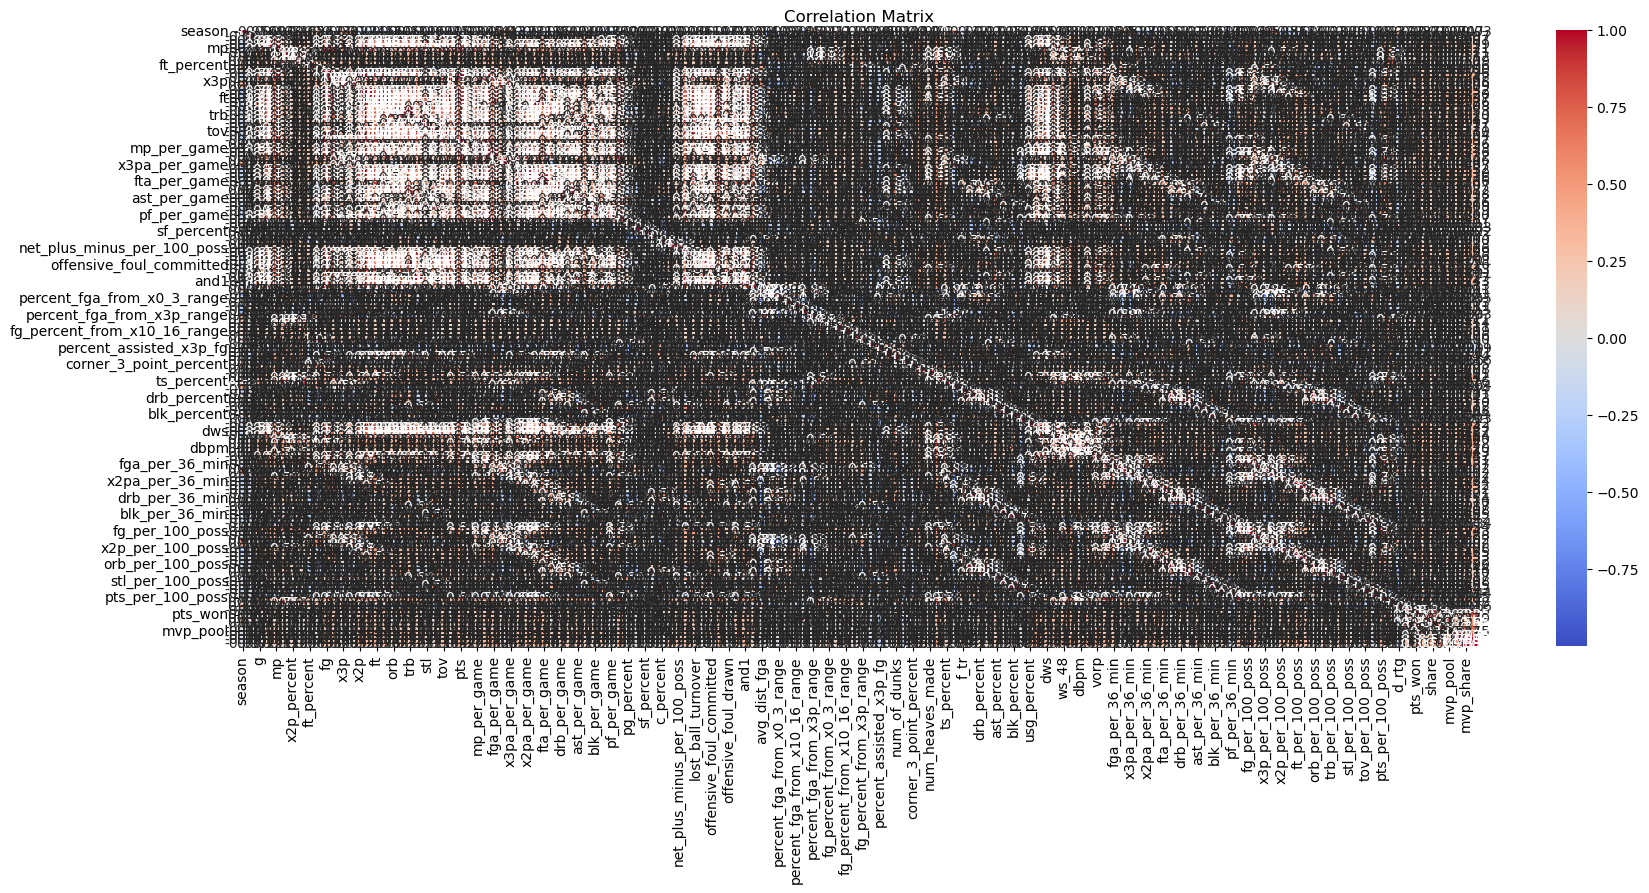

In [62]:
plt.figure(figsize=(20,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Variable Selection

In [40]:
# ---- CONFIG ----
label_col = "mvp_label"       # label column
problem_type = "regression"   # or "classification"
seed = 314
corr_threshold = 0.9

In [41]:
temp6 = temp5.drop('fg_per_36_min', 'fga_per_36_min', 'x3p_per_36_min', 'x3pa_per_36_min', \
                    'x2p_per_36_min', 'x2pa_per_36_min', 'ft_per_36_min', 'fta_per_36_min', \
                    'orb_per_36_min', 'drb_per_36_min', 'trb_per_36_min', 'ast_per_36_min', \
                    'stl_per_36_min', 'blk_per_36_min', 'tov_per_36_min', 'pf_per_36_min', \
                    'pts_per_36_min', 'x3p_ar', 'fg_percent_from_x2p_range', 'fg_percent_from_x3p_range',\
                  'stl_percent', 'trb_percent', 'orb_percent', 'drb_percent', 'blk_percent', 'fg', \
                  'x3pa', 'x2pa', 'fg_per_game', 'ast_percent', 'fga', 'drb', 'orb', 'drb_per_game', \
                  'orb_per_game', 'shooting_foul_drawn', 'and1', 'fg_per_100_poss', 'orb_per_100_poss', \
                  'drb_per_100_poss', 'shooting_foul_committed', 'lost_ball_turnover', 'bad_pass_turnover',\
                   'mp_per_game', 'fga_per_game', 'x3p_per_game', 'x3pa_per_game', 'x2p_per_game',\
                   'x2pa_per_game', 'ft_per_game', 'fta_per_game', 'trb_per_game', 'ast_per_game',\
                    'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'ws',\
                  'ws_48', 'bpm', 'mvp_pool', 'mvp_share', 'mvp_candidates', 'mvp_pts', 'share', 'pts_won', \
                   'pts_max', 'first', 'winner', 'award')

temp6.show()

[Stage 318:============================>                            (1 + 1) / 2]

+------+--------------------+---------+----+---+----+---+---+----+------+----------+-----------+------------+----------+-----------+-----+-----+---+---+-----+---+-----+----+-----+-----+----+-------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+------------------------+--------------------+---------------------------+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+--------------------------+---------------------------+----------------------------+----------------------------+-----------------------+-----------------------+--------------------+------------+------------------------+----------------------+--------------------+---------------+----+----------+-----+-----------+-----------+----+---+----+----+----+----------------+----------------+-----------------+---------------

In [42]:
# STEP 1: Select numeric columns only
# ============================================================
numeric_cols = [f.name for f in temp6.schema.fields if f.dataType.simpleString() in ('int', 'double', 'float')]
categorical_cols = [f.name for f in temp6.schema.fields if f.dataType.simpleString() == 'string']

In [43]:
numeric_cols

['season',
 'age',
 'g',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p_percent',
 'x3p',
 'x2p',
 'ft',
 'fta',
 'trb',
 'ast',
 'stl',
 'blk',
 'tov',
 'pf',
 'pts',
 'trp_dbl',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'offensive_foul_committed',
 'offensive_foul_drawn',
 'points_generated_by_assists',
 'fga_blocked',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',
 'percent_fga_from_x3_10_range',
 'percent_fga_from_x10_16_range',
 'percent_fga_from_x16_3p_range',
 'percent_fga_from_x3p_range',
 'fg_percent_from_x0_3_range',
 'fg_percent_from_x3_10_range',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x16_3p_range',
 'percent_assisted_x2p_fg',
 'percent_assisted_x3p_fg',
 'percent_dunks_of_fga',
 'num_of_dunks',
 'percent_corner_3s_of_3pa',
 'corner_3_point_percent',
 'num_heaves_attempted',
 'num_heaves_made',

In [44]:
categorical_cols

['player', 'player_id', 'lg', 'team', 'pos']

In [45]:
# 3a. Ensure all numeric columns are double type
for c in numeric_cols:
    temp6 = temp6.withColumn(c, col(c).cast(DoubleType()))

# 3b. Replace null/NaN values with 0.0 (you can use mean instead if needed)
for c in numeric_cols:
    temp6 = temp6.withColumn(c, when(col(c).isNotNull(), col(c)).otherwise(0.0))

# 3c. Filter out weird/struct names (rare Spark issue)
numeric_cols = [c for c in numeric_cols if "." not in c and not c.endswith("_VectorAssembler")]
print(f"Cleaned numeric columns ready: {len(numeric_cols)}")

Cleaned numeric columns ready: 79


In [47]:
temp6_8024 = temp6.filter(temp6.season != 2025)
temp6_2025 = temp6.filter(temp6.season == 2025)
temp6_8024.show()

+------+---------------+---------+----+---+----+---+----+----+------+----------+-----------+------------+----------+-----------+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+------+-------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+------------------------+--------------------+---------------------------+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+--------------------------+---------------------------+----------------------------+----------------------------+-----------------------+-----------------------+--------------------+------------+------------------------+----------------------+--------------------+---------------+----+----------+-----+-----------+-----------+----+---+----+----+----+----------------+----------------+-----------------+-----------

In [48]:
# 4. Correlation analysis for multicollinearity
# ======================================================
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="features_corr")
corr_data = assembler_corr.transform(temp6_8024).select("features_corr")

# Compute correlation matrix
corr_matrix = Correlation.corr(corr_data, "features_corr", "pearson").head()[0].toArray()

# Convert to DataFrame for easy inspection
corr_df = pd.DataFrame(corr_matrix, columns=numeric_cols, index=numeric_cols)

# Flatten matrix into long form (feature1, feature2, corr_value)
corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_matrix[i, j]))

# Convert to pandas DataFrame for sorting
corr_pairs_df = pd.DataFrame(corr_pairs, columns=["Feature1", "Feature2", "Correlation"])

# Add absolute correlation column for ranking
corr_pairs_df["AbsCorrelation"] = corr_pairs_df["Correlation"].abs()

# Sort descending by absolute correlation
corr_pairs_df = corr_pairs_df.sort_values(by="AbsCorrelation", ascending=False)

# Optional threshold filter
corr_threshold = 0.7
high_corr_df = corr_pairs_df[corr_pairs_df["AbsCorrelation"] > corr_threshold]

print("Top Correlations (Ranked by |r|):")
print(high_corr_df.to_string(index=False))

Top Correlations (Ranked by |r|):
                        Feature1                     Feature2  Correlation  AbsCorrelation
                              ft                          fta     0.988492        0.988492
                             x2p                          pts     0.952219        0.952219
on_court_plus_minus_per_100_poss  net_plus_minus_per_100_poss     0.939564        0.939564
                    e_fg_percent                   ts_percent     0.936509        0.936509
                              ft                          pts     0.933365        0.933365
                      fg_percent                 e_fg_percent     0.929180        0.929180
                             fta                          pts     0.926076        0.926076
                     usg_percent             fga_per_100_poss     0.925223        0.925223
                              mp                          pts     0.922584        0.922584
                 ft_per_100_poss             fta_per_100

In [49]:
#high_corr_df.to_csv("ranked_correlations.csv", index=False)

In [49]:
# VIF Analysis (pure Spark)
# ======================================================

vif_list = []

for target_col in numeric_cols:
    # Use all other columns as predictors
    input_features = [c for c in numeric_cols if c != target_col]

    # Assemble predictors
    assembler = VectorAssembler(inputCols=input_features, outputCol="features_vif")
    df_vif = assembler.transform(temp6_8024).select(col(target_col).alias("label"), "features_vif")

    # Fit linear regression
    lr = LinearRegression(featuresCol="features_vif", labelCol="label")
    lr_model = lr.fit(df_vif)

    # Compute R² and VIF
    r2 = lr_model.summary.r2
    vif = float("inf") if r2 >= 1 else 1 / (1 - r2)
    vif_list.append((target_col, r2, vif))

# Convert to DataFrame for inspection
vif_df = spark.createDataFrame(vif_list, ["Feature", "R2", "VIF"]).orderBy(col("VIF").desc())
vif_df.show(truncate=False)

25/12/05 16:35:57 WARN Instrumentation: [461a0cf2] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:36:09 WARN Instrumentation: [b70d5173] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:36:21 WARN Instrumentation: [c2390de6] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:36:32 WARN Instrumentation: [0d6b78f6] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:36:42 WARN Instrumentation: [2a831ce7] regParam is zero, which might cause numerical instability and overfitting.


...

25/12/05 16:47:31 WARN Instrumentation: [abf27576] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:47:32 WARN Instrumentation: [abf27576] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


25/12/05 16:47:40 WARN Instrumentation: [2b849a75] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:47:41 WARN Instrumentation: [2b849a75] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


+-----------------------------+------------------+------------------+
|Feature                      |R2                |VIF               |
+-----------------------------+------------------+------------------+
|ft                           |1.0               |Infinity          |
|pts                          |1.0               |Infinity          |
|x3p                          |1.0               |Infinity          |
|x2p                          |1.0               |Infinity          |
|percent_fga_from_x2p_range   |0.999969864270883 |33183.20244108013 |
|x2pa_per_100_poss            |0.9999203722477139|12558.435611834371|
|fga_per_100_poss             |0.999907000229873 |10752.714750094574|
|percent_fga_from_x0_3_range  |0.9998798266991136|8321.315904812067 |
|x3pa_per_100_poss            |0.9998085144486336|5222.326138260955 |
|pts_per_100_poss             |0.9997918755180305|4804.816764164082 |
|percent_fga_from_x3_10_range |0.9996636918629553|2973.463588444792 |
|x2p_per_100_poss   

In [50]:
vif_threshold = 10.0
selected_vif_df = vif_df.filter(col("VIF") <= vif_threshold)

In [51]:
selected_vif_df.show()

+--------------------+------------------+-----------------+
|             Feature|                R2|              VIF|
+--------------------+------------------+-----------------+
|              season|0.8914585149058335|9.213067235374915|
|         x2p_percent|0.8827835187344447| 8.53122350375361|
|    stl_per_100_poss|0.8793054837195612|8.285380569208776|
|               o_rtg|0.8791996027294943| 8.27811847142126|
|                   g|0.8787477508976069|8.247269699348312|
|fg_percent_from_x...|0.8643764849514168|7.373352619874062|
|                dbpm|0.8569608434754268|6.991092679074952|
|points_generated_...|0.8485918596877298|6.604664702555357|
|    blk_per_100_poss|0.8470893391838148|6.539766388179473|
|         fga_blocked|0.8334217053688227|6.003183081049724|
|         tov_percent|0.8312483150813368|5.925866757905208|
|                 blk|0.8245386275949322|5.699260106614312|
|percent_assisted_...|0.8120574735902354|5.320775553584581|
|                  gs| 0.804693195090619

In [52]:
selected_vif_df.count()

34

In [53]:
[row["Feature"] for row in selected_vif_df.collect()]

['season',
 'x2p_percent',
 'stl_per_100_poss',
 'o_rtg',
 'g',
 'fg_percent_from_x0_3_range',
 'dbpm',
 'points_generated_by_assists',
 'blk_per_100_poss',
 'fga_blocked',
 'tov_percent',
 'blk',
 'percent_assisted_x2p_fg',
 'gs',
 'percent_assisted_x3p_fg',
 'offensive_foul_committed',
 'd_rtg',
 'num_of_dunks',
 'pf_per_100_poss',
 'percent_dunks_of_fga',
 'f_tr',
 'x3p_percent',
 'fg_percent_from_x3_10_range',
 'corner_3_point_percent',
 'fg_percent_from_x16_3p_range',
 'ft_percent',
 'fg_percent_from_x10_16_range',
 'percent_corner_3s_of_3pa',
 'offensive_foul_drawn',
 'num_heaves_attempted',
 'trp_dbl',
 'age',
 'num_heaves_made',
 'mvp_label']

In [54]:
selected_features=[row["Feature"] for row in selected_vif_df.collect()]

In [55]:
# 5. Backward Elimination (using VIF-selected variables)
# ======================================================
def backward_elimination(df, features, label_col):
    remaining = features.copy()
    best_model = None
    last_rmse = float("inf")

    while len(remaining) > 1:
        rmse_results = []
        for feat in remaining:
            subset = [f for f in remaining if f != feat]
            assembler = VectorAssembler(inputCols=subset, outputCol="features")
            df_subset = assembler.transform(df).select("features", label_col)
            model = LinearRegression(featuresCol="features", labelCol=label_col)
            lr_model = model.fit(df_subset)
            rmse = lr_model.summary.rootMeanSquaredError
            rmse_results.append((feat, rmse))
        
        # find worst variable (whose removal improves RMSE)
        worst_feat, worst_rmse = max(rmse_results, key=lambda x: x[1])

        if worst_rmse < last_rmse:
            last_rmse = worst_rmse
            remaining.remove(worst_feat)
            best_model = (remaining.copy(), last_rmse)
        else:
            break
    return best_model



In [56]:
# Run backward elimination on the selected features
label_col = "mvp_label"  # label column
best_features, best_rmse = backward_elimination(temp6_8024, selected_features, label_col)

print("\n=== Final Selected Features (after Backward Elimination) ===")
for f in best_features:
    print(f)

print(f"\nFinal RMSE: {best_rmse:.4f}")

25/12/05 16:55:51 WARN Instrumentation: [e5fe11cc] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:56:00 WARN Instrumentation: [2cd56582] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:56:08 WARN Instrumentation: [7a64c6cf] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 16:56:17 WARN Instrumentation: [0ada6c2e] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:56:27 WARN Instrumentation: [1458e268] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 16:56:37 WARN Instrumentation: [8097823c] regParam is zero, which might cause numerical instability and overfitting.


...

25/12/05 17:04:05 WARN Instrumentation: [471c4f7e] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:04:13 WARN Instrumentation: [19ef478c] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:04:22 WARN Instrumentation: [dcbf502f] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:04:30 WARN Instrumentation: [699acd78] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:04:39 WARN Instrumentation: [d90040cb] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:04:48 WARN Instrumentation: [b4d8cd1c] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:04:56 WARN Instrumentation: [5af678ec] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:05:04 WARN Instrumentation: [81df61c7] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:05:13 WARN Instrumentation: [9707a469] regParam is zero, which might cause numerical instability and overfitting.

=== Final Selected Features (after Backward Elimination) ===
season
x2p_percent
stl_per_100_poss
o_rtg
g
fg_percent_from_x0_3_range
dbpm
points_generated_by_assists
blk_per_100_poss
fga_blocked
tov_percent
blk
percent_assisted_x2p_fg
gs
percent_assisted_x3p_fg
offensive_foul_committed
d_rtg
num_of_dunks
pf_per_100_poss
percent_dunks_of_fga
f_tr
x3p_percent
fg_percent_from_x3_10_range
corner_3_point_percent
fg_percent_from_x16_3p_range
ft_percent
fg_percent_from_x10_16_range
percent_corner_3s_of_3pa
offensive_foul_drawn
num_heaves_attempted
trp_dbl
age
num_heaves_made

Final RMSE: 0.0419


In [57]:
best_features

['season',
 'x2p_percent',
 'stl_per_100_poss',
 'o_rtg',
 'g',
 'fg_percent_from_x0_3_range',
 'dbpm',
 'points_generated_by_assists',
 'blk_per_100_poss',
 'fga_blocked',
 'tov_percent',
 'blk',
 'percent_assisted_x2p_fg',
 'gs',
 'percent_assisted_x3p_fg',
 'offensive_foul_committed',
 'd_rtg',
 'num_of_dunks',
 'pf_per_100_poss',
 'percent_dunks_of_fga',
 'f_tr',
 'x3p_percent',
 'fg_percent_from_x3_10_range',
 'corner_3_point_percent',
 'fg_percent_from_x16_3p_range',
 'ft_percent',
 'fg_percent_from_x10_16_range',
 'percent_corner_3s_of_3pa',
 'offensive_foul_drawn',
 'num_heaves_attempted',
 'trp_dbl',
 'age',
 'num_heaves_made']

In [58]:
# 7. Forward Selection
# ======================================================
def forward_selection(df, features, label_col):
    selected = []
    remaining = features.copy()
    best_model = None
    last_rmse = float("inf")

    while remaining:
        rmse_results = []
        for feat in remaining:
            subset = selected + [feat]
            assembler = VectorAssembler(inputCols=subset, outputCol="features")
            df_subset = assembler.transform(df).select("features", label_col)
            model = LinearRegression(featuresCol="features", labelCol=label_col)
            lr_model = model.fit(df_subset)
            rmse = lr_model.summary.rootMeanSquaredError
            rmse_results.append((feat, rmse))
        
        best_feat, best_rmse = min(rmse_results, key=lambda x: x[1])
        if best_rmse < last_rmse:
            last_rmse = best_rmse
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_model = (selected.copy(), last_rmse)
        else:
            break
    return best_model



In [59]:
# ======================================================
# Run Forward Selection using the backward-selected variables
# Make sure `best_features` and `label_col` are defined from previous step
best_forward_features, best_forward_rmse = forward_selection(temp6_8024, best_features, label_col)


25/12/05 17:06:30 WARN Instrumentation: [810484bd] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:06:36 WARN Instrumentation: [ea713621] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:06:42 WARN Instrumentation: [abbe6a02] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:06:48 WARN Instrumentation: [b9fa1506] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:06:54 WARN Instrumentation: [20b9d3db] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:00 WARN Instrumentation: [cf507835] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:07:06 WARN Instrumentation: [1aafad0f] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:12 WARN Instrumentation: [c87c0511] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:18 WARN Instrumentation: [3ea93f6f] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:24 WARN Instrumentation: [c96e2215] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:29 WARN Instrumentation: [12980ce2] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:35 WARN Instrumentation: [6f844e5e] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:40 WARN Instrumentation: [185634cf] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:07:46 WARN Instrumentation: [5ce67bc5] regParam is zero, which might cause numerical instability and overf

25/12/05 17:21:39 WARN Instrumentation: [f36cd2ed] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:21:44 WARN Instrumentation: [79124265] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:21:50 WARN Instrumentation: [2cefbc17] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 17:21:56 WARN Instrumentation: [a11fd773] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:01 WARN Instrumentation: [26272afa] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:07 WARN Instrumentation: [a6c9de9a] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:13 WARN Instrumentation: [a5bea271] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:18 WARN Instrumentation: [681c048a] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:24 WARN Instrumentation: [89064ffa] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:29 WARN Instrumentation: [64cdaf3a] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:22:34 WARN Instrumentation: [c294b6cb] regParam is zero, which might cause numerical instability and overf

25/12/05 17:23:58 WARN Instrumentation: [7354aeea] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:04 WARN Instrumentation: [3060dcad] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:10 WARN Instrumentation: [baec0e30] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:15 WARN Instrumentation: [e476de38] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:21 WARN Instrumentation: [98e16117] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:27 WARN Instrumentation: [33332c88] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:33 WARN Instrumentation: [be3a85f8] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 17:24:38 WARN Instrumentation: [aa0c7c95] regParam is zero, which might cause numerical instability and overf

...

25/12/05 18:01:13 WARN Instrumentation: [ddb2bcb2] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 18:01:21 WARN Instrumentation: [b48e7e23] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 18:01:29 WARN Instrumentation: [aaf2d455] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 18:01:37 WARN Instrumentation: [86c45243] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 18:01:46 WARN Instrumentation: [83f71faf] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 18:01:53 WARN Instrumentation: [d5f06863] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 18:02:02 WARN Instrumentation: [0e7df4bd] regParam is zero, which might cause numerical instability and overfitting.


25/12/05 18:02:11 WARN Instrumentation: [e9e88550] regParam is zero, which might cause numerical instability and overfitting.
25/12/05 18:02:20 WARN Instrumentation: [7e8e45d4] regParam is zero, which might cause numerical instability and overfitting.


In [60]:
best_forward_features

['trp_dbl',
 'blk',
 'd_rtg',
 'blk_per_100_poss',
 'num_heaves_attempted',
 'g',
 'o_rtg',
 'percent_dunks_of_fga',
 'num_of_dunks',
 'offensive_foul_committed',
 'points_generated_by_assists',
 'offensive_foul_drawn',
 'percent_assisted_x3p_fg',
 'x3p_percent',
 'corner_3_point_percent',
 'stl_per_100_poss',
 'pf_per_100_poss',
 'dbpm',
 'percent_corner_3s_of_3pa',
 'tov_percent',
 'ft_percent',
 'x2p_percent',
 'age',
 'f_tr',
 'fga_blocked',
 'gs',
 'fg_percent_from_x16_3p_range',
 'percent_assisted_x2p_fg',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x3_10_range',
 'num_heaves_made',
 'season',
 'fg_percent_from_x0_3_range']

In [61]:
final_features = best_forward_features  # from previous step
label_col = "mvp_label"
# Assemble feature vector
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_model = assembler.transform(temp6_8024).select("features", label_col)

# Optional: Split data for training/testing
train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=seed)

In [62]:
# Logistic Regression
log_reg = LogisticRegression(featuresCol="features", labelCol=label_col)
log_model = log_reg.fit(train_df)
log_predictions = log_model.transform(test_df)

# Evaluate
evaluator = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction")
log_auc = evaluator.evaluate(log_predictions)
print(f"\nLogistic Regression AUC: {log_auc:.4f}")


Logistic Regression AUC: 0.9926


In [63]:
# Random Forest

rf = RandomForestClassifier(featuresCol="features", labelCol=label_col, numTrees=100, seed=42)
rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_auc = evaluator.evaluate(rf_predictions)
print(f"Random Forest AUC: {rf_auc:.4f}")

Random Forest AUC: 0.9778


In [64]:
# Feature Importance (Random Forest)
feature_importances = list(zip(final_features, rf_model.featureImportances.toArray()))
feature_importances_sorted = sorted(feature_importances, key=lambda x: x[1], reverse=True)

print("\nTop Feature Importances (Random Forest):")
for feat, imp in feature_importances_sorted[:10]:
    print(f"{feat}: {imp:.4f}")


Top Feature Importances (Random Forest):
trp_dbl: 0.1944
dbpm: 0.0688
num_heaves_attempted: 0.0513
d_rtg: 0.0426
o_rtg: 0.0393
ft_percent: 0.0368
season: 0.0324
x2p_percent: 0.0323
x3p_percent: 0.0315
stl_per_100_poss: 0.0307


In [65]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

# 2. Use the SAME selected features and assembler as for 1980–2024
#    (final_features and assembler are already defined in your notebook)
#    final_features = best_forward_features
#    assembler = VectorAssembler(inputCols=final_features, outputCol="features")

df_2025 = assembler.transform(temp6_2025)

# 3. Get predictions for 2025 using your trained model
#    Choose whichever model you want: log_model or rf_model
pred_2025_log = log_model.transform(df_2025)      # or: rf_model.transform(df_2025)
pred_2025_rf = rf_model.transform(df_2025)

# 4. Extract probability of the positive class (mvp_label = 1)
get_prob_mvp = udf(lambda v: float(v[1]), DoubleType())  # assumes label 1 = MVP
pred_2025_log = pred_2025_log.withColumn("p_mvp", get_prob_mvp(col("probability")))
pred_2025_rf = pred_2025_rf.withColumn("p_mvp", get_prob_mvp(col("probability")))

# 5. Show top MVP candidates for 2025
#    Replace "player" and "team" with your actual column names if different
pred_2025_log.select(
    "season",
    "player",
    "team",
    "p_mvp",
    "prediction"
).orderBy(col("p_mvp").desc()).show(20, truncate=False)

pred_2025_rf.select(
    "season",
    "player",
    "team",
    "p_mvp",
    "prediction"
).orderBy(col("p_mvp").desc()).show(20, truncate=False)

+------+-----------------------+----+---------------------+----------+
|season|player                 |team|p_mvp                |prediction|
+------+-----------------------+----+---------------------+----------+
|2025.0|Nikola Jokić           |DEN |0.9513008993998816   |1.0       |
|2025.0|Shai Gilgeous-Alexander|OKC |0.27221760099146375  |0.0       |
|2025.0|James Harden           |LAC |0.049756671038787226 |0.0       |
|2025.0|Stephen Curry          |GSW |0.021865821199584246 |0.0       |
|2025.0|Payton Pritchard       |BOS |0.010210927282167326 |0.0       |
|2025.0|LeBron James           |LAL |0.008311303991080377 |0.0       |
|2025.0|Anthony Edwards        |MIN |0.004414039629030975 |0.0       |
|2025.0|Tyrese Haliburton      |IND |0.0041742826651061105|0.0       |
|2025.0|Jayson Tatum           |BOS |0.003671830554047184 |0.0       |
|2025.0|Damian Lillard         |MIL |0.0026996979782273334|0.0       |
|2025.0|Giannis Antetokounmpo  |MIL |0.0026439718467909934|0.0       |
|2025.

In [66]:
#In case the above cell breaks.

from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler

# -----------------------------------------
# 1. Filter 2025 season
# -----------------------------------------

# -----------------------------------------
# 2. Assemble features (same as training)
# -----------------------------------------
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_2025 = assembler.transform(temp6_2025)

# -----------------------------------------
# 3. Get predictions from BOTH models
# -----------------------------------------

# Logistic Regression
log_pred = log_model.transform(df_2025).withColumnRenamed(
    "probability", "log_probability"
)

# Random Forest
rf_pred = rf_model.transform(df_2025).withColumnRenamed(
    "probability", "rf_probability"
)

# -----------------------------------------
# 4. Extract probability of MVP class (=1)
# -----------------------------------------
get_prob = udf(lambda v: float(v[1]), DoubleType())

log_pred = log_pred.withColumn("log_p_mvp", get_prob(col("log_probability")))
rf_pred = rf_pred.withColumn("rf_p_mvp", get_prob(col("rf_probability")))

# -----------------------------------------
# 5. Join LR + RF predictions side-by-side
# -----------------------------------------

# Use a unique player-season identifier — change "player" if your column name differs.
compare_2025 = (
    log_pred.select("player", "team", "season", "log_p_mvp")
    .join(
        rf_pred.select("player", "rf_p_mvp"),
        on="player",
        how="inner"
    )
)

# -----------------------------------------
# 6. Show top candidates by BOTH models
# -----------------------------------------
compare_2025.orderBy(col("log_p_mvp").desc()).show(20, truncate=False)
compare_2025.orderBy(col("rf_p_mvp").desc()).show(20, truncate=False)

# -----------------------------------------
# 7. Combined view sorted by average predicted MVP probability
# -----------------------------------------
compare_2025 = compare_2025.withColumn(
    "avg_mvp_score", (col("log_p_mvp") + col("rf_p_mvp")) / 2
)

compare_2025.orderBy(col("avg_mvp_score").desc()).show(20, truncate=False)


+-----------------------+----+------+---------------------+---------------------+
|player                 |team|season|log_p_mvp            |rf_p_mvp             |
+-----------------------+----+------+---------------------+---------------------+
|Nikola Jokić           |DEN |2025.0|0.9513008993998816   |0.41380492623616744  |
|Shai Gilgeous-Alexander|OKC |2025.0|0.27221760099146375  |0.047712461532950654 |
|James Harden           |LAC |2025.0|0.049756671038787226 |0.01639460398779995  |
|Stephen Curry          |GSW |2025.0|0.021865821199584246 |0.0025904967440307635|
|Payton Pritchard       |BOS |2025.0|0.010210927282167326 |0.0242757134357876   |
|LeBron James           |LAL |2025.0|0.008311303991080377 |0.036011540964011574 |
|Anthony Edwards        |MIN |2025.0|0.004414039629030975 |0.01314803072524218  |
|Tyrese Haliburton      |IND |2025.0|0.0041742826651061105|0.04361379954436982  |
|Jayson Tatum           |BOS |2025.0|0.003671830554047184 |0.003958349480364844 |
|Damian Lillard 